**Problem Definition**

Main Problem

Predict traffic volume/congestion using historical traffic data.

Questions
What times have highest congestion?
Which factors affect traffic most?
Can machine learning accurately predict traffic flow?
Hypothesis

Traffic congestion depends on the Time and Day

In [63]:
#Data Collection
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("hasibullahaman/traffic-prediction-dataset")

print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'traffic-prediction-dataset' dataset.
/kaggle/input/traffic-prediction-dataset
['Traffic.csv', 'TrafficTwoMonth.csv']


In [64]:
df1 = pd.read_csv(os.path.join(path, "Traffic.csv"))
df2 = pd.read_csv(os.path.join(path, "TrafficTwoMonth.csv"))

In [65]:
#Data Cleaning & Preparation
#df1[:10]
#df2[:10]
df = pd.concat([df1, df2], ignore_index=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df[:10]

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal
5,1:15:00 AM,10,Tuesday,44,0,5,4,53,low
6,1:30:00 AM,10,Tuesday,37,0,1,4,42,low
7,1:45:00 AM,10,Tuesday,42,4,4,5,55,low
8,2:00:00 AM,10,Tuesday,51,0,9,7,67,low
9,2:15:00 AM,10,Tuesday,34,0,4,7,45,low


In [66]:
df.isnull().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [67]:
import numpy as np
for col in df.columns:
    null_indices = np.random.choice(df.index, 10, replace=False)
    df.loc[null_indices, col] = np.nan
df.isnull().sum()

,0
Time,10
Date,10
Day of the week,10
CarCount,10
BikeCount,10
BusCount,10
TruckCount,10
Total,10
Traffic Situation,10


In [68]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [69]:
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,6234.000000,6234.000000,6234.000000,6234.000000,6234.000000,6234.000000
mean,16.049567,64.347289,12.032884,12.549727,18.643086,107.572987
std,8.951746,44.284745,11.388620,12.315112,10.708953,55.853713
min,1.000000,5.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,18.000000,3.000000,1.000000,10.000000,53.000000
50%,16.000000,61.000000,9.000000,10.000000,18.000000,103.000000
75%,24.000000,101.000000,19.000000,20.000000,27.000000,151.000000
max,31.000000,180.000000,70.000000,50.000000,60.000000,279.000000


In [70]:
#Exploratory Data Analysis (EDA)
df.info()
df.describe()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 6234 entries, 0 to 6323
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               6234 non-null   object 
 1   Date               6234 non-null   float64
 2   Day of the week    6234 non-null   object 
 3   CarCount           6234 non-null   float64
 4   BikeCount          6234 non-null   float64
 5   BusCount           6234 non-null   float64
 6   TruckCount         6234 non-null   float64
 7   Total              6234 non-null   float64
 8   Traffic Situation  6234 non-null   object 
dtypes: float64(6), object(3)
memory usage: 487.0+ KB
(6234, 9)


In [71]:
avg_day = df.groupby("Day of the week")["Total"].mean()

print(avg_day)

Day of the week
Friday       103.086165
Monday       107.770000
Saturday     108.006196
Sunday       109.298637
Thursday     107.599600
Tuesday      108.096614
Wednesday    108.826788
Name: Total, dtype: float64


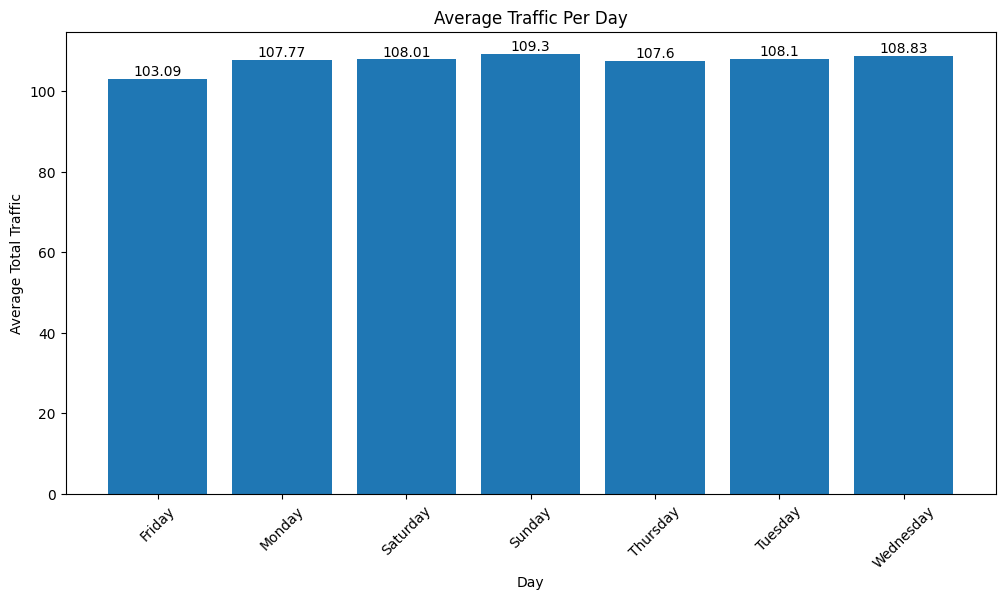

In [72]:
import matplotlib.pyplot as plt

avg_traffic = df.groupby("Day of the week")["Total"].mean()

plt.figure(figsize=(12, 6))

bars = plt.bar(avg_traffic.index, avg_traffic.values)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval, 2),
        ha='center',
        va='bottom'
    )

plt.xlabel("Day")
plt.ylabel("Average Total Traffic")
plt.title("Average Traffic Per Day")

plt.xticks(rotation=45)

plt.show()

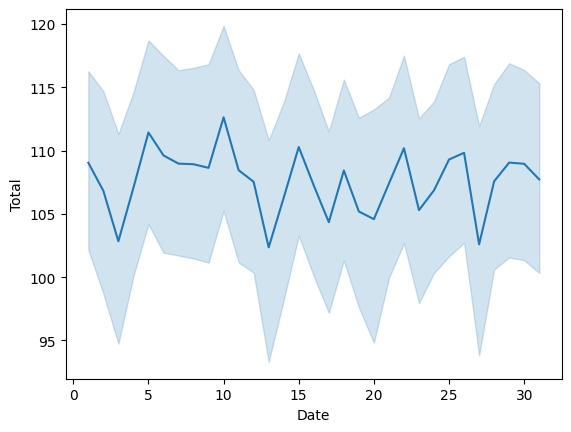

In [73]:
sns.lineplot(x='Date',
             y='Total',
             data=df)
plt.show()

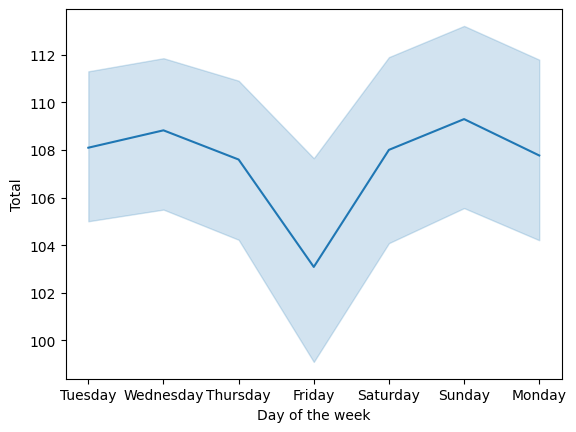

In [83]:
sns.lineplot(x='Day of the week',y='Total',data=df)
plt.show()

In [75]:
print(df.corr(numeric_only=True))

                Date  CarCount  BikeCount  BusCount  TruckCount     Total
Date        1.000000 -0.008063  -0.000680 -0.005403    0.019991 -0.003890
CarCount   -0.008063  1.000000   0.706065  0.664232   -0.584080  0.971306
BikeCount  -0.000680  0.706065   1.000000  0.580442   -0.584823  0.779570
BusCount   -0.005403  0.664232   0.580442  1.000000   -0.532381  0.763417
TruckCount  0.019991 -0.584080  -0.584823 -0.532381    1.000000 -0.507997
Total      -0.003890  0.971306   0.779570  0.763417   -0.507997  1.000000


In [76]:
df['Time'] = pd.to_datetime(df['Time'])

df['Time'] = (
    df['Time'].dt.hour +
    df['Time'].dt.minute / 60
)

/tmp/ipykernel_22079/3096402891.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [77]:
from sklearn.model_selection import train_test_split

X = df.drop(['Total', 'Traffic Situation', 'Day of the week'], axis=1)
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]]
y = df["Traffic Situation"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [79]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[220   0   0   0]
 [  0  66   0  26]
 [  0   0 126  43]
 [  0  27  38 701]]


In [102]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Traffic_Label"] = encoder.fit_transform(df["Traffic Situation"])
print(df["Traffic_Label"].unique())

[2 3 0 1]


In [81]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Encode labels
encoder = LabelEncoder()

df["Traffic_Label"] = encoder.fit_transform(df["Traffic Situation"])

# Features
X = df[["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]]

# Target
y = df["Traffic_Label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = RandomForestClassifier()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)


print("MAE:", mae)
print("MSE:", mse)

MAE: 0.15236567762630313
MSE: 0.2421812349639134


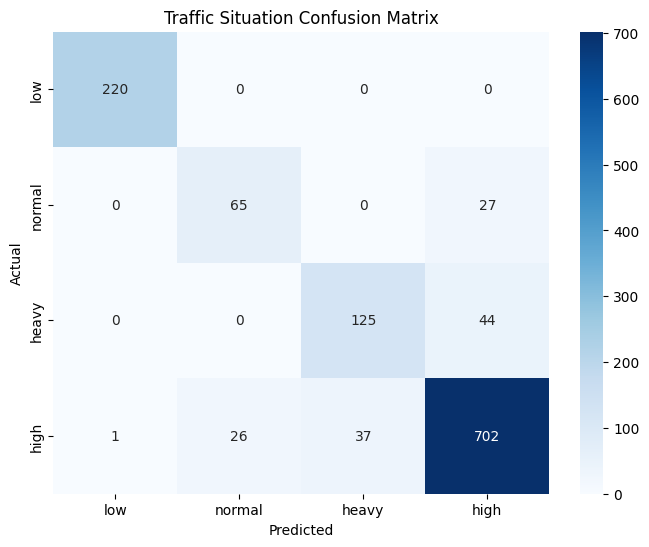

In [82]:
labels = df["Traffic Situation"].unique()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Traffic Situation Confusion Matrix")

plt.show()

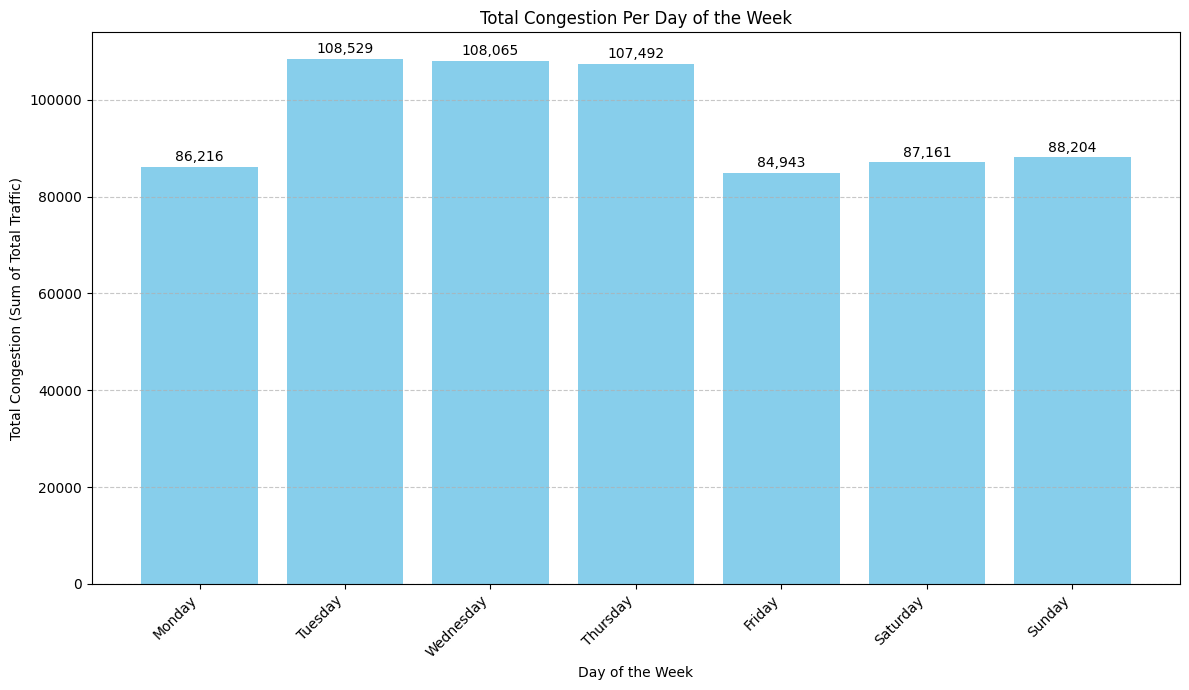

In [105]:
# Calculate the sum of 'Total' traffic for each 'Day of the week'
total_congestion_per_day = df.groupby('Day of the week')['Total'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Create a bar chart
plt.figure(figsize=(12, 7))
plt.bar(total_congestion_per_day.index, total_congestion_per_day.values, color='skyblue')

# Add values on top of bars
for index, value in enumerate(total_congestion_per_day.values):
    plt.text(index, value + 500, f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

plt.xlabel("Day of the Week")
plt.ylabel("Total Congestion (Sum of Total Traffic)")
plt.title("Total Congestion Per Day of the Week")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()